In [80]:

import pandas as pd
import re 
import nltk
import numpy as np

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Azeroual\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [81]:



print("Setup OK")

Setup OK


In [82]:
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Azeroual\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Azeroual\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [ ]:
#Chargement de dataset 

df = pd.read_csv(
    "SMSSpamCollection",
    sep="\t",
    header=None,
    names=["label", "message"]
)
df.to_csv("SMSSpamAugment.csv", index=False)

## <span style="color:#A23B72">Partie 1 — Nettoyage des Données</span>

In [84]:
df = pd.read_csv("SMSSpam.csv")

In [85]:
def cal_moyene() :
    nombres = df["word_count"] = df["message"].str.split().str.len().tolist()
    nombre = 0
    for e in nombres :
        nombre += e
    return(nombre / df.shape[0])

In [86]:
#Analyse 

nbr_totles = df.shape[0]
print("Nombres totales des examples",nbr_totles)
print("Répartition des classes" ,df['label'].unique())
print("Longueur moyenne des messages",cal_moyene())



Nombres totales des examples 5572
Répartition des classes <StringArray>
['ham', 'spam']
Length: 2, dtype: str
Longueur moyenne des messages 15.597451543431443


In [87]:
# Identi er la présence éventuelle de 

df["has_punctuation"] = df["message"].str.contains(r"[^\w\s]", regex=True)
df["has_digits"] = df["message"].str.contains(r"\d", regex=True)
df["has_url"] = df["message"].str.contains(r"http[s]?://|www\.", regex=True)
df["has_special_chars"] = df["message"].str.contains(r"[@#$%^&*()_+=<>]", regex=True)
df["has_uppercase"] = df["message"].str.contains(r"[A-Z]", regex=True)
df["has_emoji"] = df["message"].str.contains(r"[\U0001F600-\U0001F64F]", regex=True)

df.to_csv("SMSSpam.csv", index=False)

Nettoyage minimal à tester

In [88]:
#Mise en minuscules
df['message'] = df['message'].str.lower()
#Suppression de la ponctuation
df['message'] = df['message'].str.replace(r"[^\w\s]","",regex=True)
#Suppression des chiffres
df['message'] = df['message'].str.replace(r"[\d]", "",regex=True)
#Suppression des caractères spéciaux
df['message'] = df['message'].str.replace(r"[@#$%^&*()_+=<>]","", regex=True)

df.to_csv("SMSSpamMinimal.csv", index=False)

# Questions d'analyse

### Le nettoyage améliore-t-il systématiquement les performances ?

Oui, je vois que la longueur moyenne diminue.

### Peut-on supprimer des informations utiles en nettoyant trop agressivement ?

Oui, on supprime les doublons, les lettres dupliquées dans les mots.

In [89]:

#Supprimer répétition excessive des lettres
def remove_duplicate_charactere(text) :
    return re.sub(r"(.)\1{2,}", r"\1\1", text)

#Supprimer les mots doublés
def remove_duplicate_words(text) :
    words = text.split()
    unique_words = list(dict.fromkeys(words))
    return " ".join(unique_words)
df['message'] = df['message'].apply(remove_duplicate_words)
df['message'] = df['message'].apply(remove_duplicate_charactere)

df.to_csv("SMSSpamMinimal.csv", index=False)


## <span style="color:#A23B72">Partie 2 — Prétraitement Linguistique</span>

In [90]:
def remove_stopwords(words , stop_words):
    sans_stpwords = []
    for word in words :
        if word not in stop_words and len(word) >= 2:
            sans_stpwords.append(word)
    return sans_stpwords

def apply_Stemming(words,stemmer):
    return [stemmer.stem(word) for word in words]

def apply_lemmatization(words,lemmatizer):
    return [lemmatizer.lemmatize(word) for word in words]

In [91]:
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
#Tokenisation

df['tokens'] = df['message'].str.split()
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

df['tokens'] = df['tokens'].apply(lambda words: remove_stopwords(words, stop_words))
df['tokens'] = df['tokens'].apply(lambda words: apply_lemmatization(words, lemmatizer))
df.to_csv("SMSSpamAvance.csv", index=False)

In [92]:
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
#Tokenisation

df['tokens'] = df['message'].str.split()
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

df['tokens'] = df['tokens'].apply(lambda words: remove_stopwords(words, stop_words))
df['tokens'] = df['tokens'].apply(lambda words: apply_Stemming(words, stemmer))
df.to_csv("SMSSpamMinima.csv", index=False)

# Questions d'analyse

## Quelle différence observez-vous entre stemming et lemmatisation ?

Les mots obtenus après la lemmatisation sont plus corrects et logiques que ceux du stemming. 

- Le stemming coupe simplement les mots sans tenir compte de leur sens
- La lemmatisation cherche la forme normale du mot (lemme) en utilisant un dictionnaire et l'analyse grammaticale

## La suppression des stopwords est-elle toujours pertinente dans un problème de spam ?

Non, la suppression des stopwords n'est pas toujours utile pour la détection de spam. 

Après une vérification manuelle, on constate que certains de ces mots courants peuvent aider à identifier les messages spam.

## <span style="color:#A23B72">Partie 3 — Vectorisation</span>

## <span style="color:#E23B55">Bag of Words (CountVectorizer)</span>

In [93]:
import ast

# Convertir la chaîne de liste en vraie liste, puis rejoindre en string
def tokens_to_text(tokens_str):
    try:
        tokens = ast.literal_eval(tokens_str) 
        return " ".join(tokens)               
    except:
        return ""

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

In [95]:
from gensim.models import Word2Vec

### Avec Tokens de df SMSSpamAvance

In [96]:
#transformer les tokens en string car Bag of Words ateind des strings
df = pd.read_csv('SMSSpamAvance.csv')
df['bagWords'] = df['tokens'].apply(lambda words: tokens_to_text(words))

# Nettoyer les NaN avant vectorisation
tokens = df['bagWords'].fillna('').astype(str)
message = df['message'].fillna('').astype(str)

df.to_csv("SMSSpamBagofWords.csv", index=False)

# Initialiser CountVectorizer
vectorizer = CountVectorizer()
vectorizer_message = CountVectorizer()

# Transformer les textes en matrice de comptage
X_tokens = vectorizer.fit_transform(tokens)
X_message = vectorizer_message.fit_transform(message)

# X est une matrice creuse (sparse)
print(f"Shape de la matrice : {X_tokens.shape}")

# Voir le vocabulaire (premiers mots)
print("Vocabulaire (exemples) :", vectorizer.get_feature_names_out()[:10])

# Voir la matrice pour les 3 premières lignes
print("Matrice tokens (3 premières lignes) :")
print(X_tokens[:3].toarray())
print("Matrice message (3 premières lignes) :")
print(X_message[:3].toarray())

X_bagofwords = X_tokens  

Shape de la matrice : (5572, 7922)
Vocabulaire (exemples) : ['aa' 'aah' 'aaniye' 'aaooright' 'aathilove' 'aathiwhere' 'ab' 'abbey'
 'abdomen' 'abeg']
Matrice tokens (3 premières lignes) :
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
Matrice message (3 premières lignes) :
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


## <span style="color:#E23B55">TF-IDF</span>

In [97]:
# Utiliser directement la colonne bagWords
vectorizer = TfidfVectorizer()

X_tf_idf= vectorizer.fit_transform(df["bagWords"])
y = df["label"]
print("Nombre de mots dans le vocabulaire :", len(vectorizer.get_feature_names_out()))
print("\nExemple de mots :")
print(vectorizer.get_feature_names_out()[:20])
print("\nDimensions de la matrice TF-IDF :", X_tf_idf.shape)

print("\nTF-IDF des 2 premiers messages :")
print(X_tf_idf[:2].toarray())


Nombre de mots dans le vocabulaire : 7922

Exemple de mots :
['aa' 'aah' 'aaniye' 'aaooright' 'aathilove' 'aathiwhere' 'ab' 'abbey'
 'abdomen' 'abeg' 'abelu' 'aberdeen' 'abi' 'ability' 'abiola' 'abj' 'able'
 'abnormally' 'aboutas' 'abroad']

Dimensions de la matrice TF-IDF : (5572, 7922)

TF-IDF des 2 premiers messages :
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


## <span style="color:#E23B55">Word Embeddings
</span>

In [98]:
# 4. Fonction pour calculer la MOYENNE des vecteurs
def get_message_vector(tokens_list, model, vector_size=100):
    # Récupérer le vecteur de CHAQUE mot individuellement
    vectors = [model.wv[word] for word in tokens_list if word in model.wv]
    
    # Si aucun mot connu, retourner des zéros
    if len(vectors) == 0:
        return np.zeros(vector_size)
    
    # Retourner la MOYENNE de tous les vecteurs
    return np.mean(vectors, axis=0)

In [116]:
from gensim.models import Word2Vec

# utiliser ta colonne tokens
sentences = df["tokens"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x).tolist()

model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4
)


df['W2V'] = df['tokens'].apply(lambda words: applyAvrage(words,model))
df.to_csv("SMSSpamAvance.csv", index=False)
print(model.wv["go"])

[-0.21814457  0.32870728  0.11942998  0.07313491 -0.01732442 -0.7626593
  0.14794503  1.1366984  -0.20253952 -0.23672862 -0.25391915 -0.71536463
 -0.09544863  0.1799475  -0.01370129 -0.42500666 -0.0761461  -0.73371637
 -0.13413672 -0.92413974  0.28792864  0.2786613   0.27635175 -0.15661608
 -0.1665164   0.02583378 -0.49360356 -0.39589363 -0.46225867  0.0786793
  0.455032    0.13286357  0.18112972 -0.27328756 -0.25096545  0.43804342
 -0.07568946 -0.5584488  -0.30974826 -0.9288604   0.04138806 -0.4124523
 -0.27951235 -0.02828808  0.4399019  -0.33695856 -0.28742474 -0.07072329
  0.37872177  0.38509914  0.20605302 -0.48099825 -0.14664121 -0.14510375
 -0.27769783  0.2496636   0.15679221 -0.12571046 -0.5283333   0.1290311
  0.07454685  0.182605   -0.1789683   0.05873058 -0.6924521   0.43692267
  0.14461064  0.36364704 -0.6107006   0.64763457 -0.1808026   0.3121386
  0.5912474  -0.22489044  0.59753966  0.32803273  0.01323846 -0.1924174
 -0.35754532  0.13743643 -0.3591104  -0.10439222 -0.40163

# Réponses Courtes – Analyse NLP  
*Préparation examen — Étudiant en Data Engineering*

---

## 1️⃣ Méthode qui capture le mieux la sémantique ?

> **✅ Réponse : Les embeddings Word2Vec (Gensim)**

🔹 **Pourquoi ?**  
Contrairement à **BoW** ou **TF-IDF** qui traitent les mots de façon isolée, **Word2Vec** apprend le **contexte** et les **relations sémantiques** entre les mots.

💡 **Exemple :**  
`"roi" ≈ "reine"` → vecteurs proches dans l'espace vectoriel ✅  
`"roi" ≠ "pomme"` → vecteurs éloignés

---

## 2️⃣ Pourquoi TF-IDF est souvent meilleur que BoW ?

> **✅ Réponse : TF-IDF pondère intelligemment les mots**

| Méthode | Principe | Problème |
|---------|----------|----------|
| **BoW** | Compte brut des mots | "le", "de", "un" ont trop d'impact ❌ |
| **TF-IDF** | Pondere par rareté et importance | Met en avant les mots discriminants ✅ |

🎯 **Résultat :** Meilleure séparation spam/ham car TF-IDF réduit le bruit des mots fréquents et valorise les mots rares comme "gratuit" ou "urgent".

---

## 3️⃣ Avantages et limites des embeddings sur petit dataset ?

> **✅ Réponse : Puissant mais à utiliser avec précaution**

🟢 **Avantages**  
• 🧠 Capture le sens et les synonymes  
• 📏 Vecteur de taille fixe (ex: 100)  
• 🔄 Réutilisable avec modèles pré-entraînés  

🔴 **Limites**  
• 📉 Besoin de beaucoup de données pour bien apprendre  
• 🎭 Risque d'overfitting sur petit dataset  
• ⏱️ Plus lent à entraîner que TF-IDF  
• 🔍 Difficile à interpréter/déboguer

---


## <span style="color:#A23B72">Partie 4 — Classification</span>

🔹 1️⃣ Préparation commune

In [100]:
import pandas as pd
from sklearn.model_selection import train_test_split

df_min = pd.read_csv("SMSSpamMinima.csv")
df_adv = pd.read_csv("SMSSpamAvance.csv")

y_min = df_min["label"]
y_adv = df_adv["label"]

# transformer tokens en texte
df_min["text"] = df_min["tokens"].astype(str)
df_adv["text"] = df_adv["tokens"].astype(str)

X_train_min, X_test_min, y_train_min, y_test_min = train_test_split(
    df_min["text"], y_min, test_size=0.2, random_state=42
)

X_train_adv, X_test_adv, y_train_adv, y_test_adv = train_test_split(
    df_adv["text"], y_adv, test_size=0.2, random_state=42
)

🟢 PIPELINE 1
✅ Minimal + BoW + Logistic Regression

In [101]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression

pipeline_1 = Pipeline([
    ("vectorizer", CountVectorizer()),
    ("classifier", LogisticRegression(max_iter=1000))
])

pipeline_1.fit(X_train_min, y_train_min)
y_pred_1 = pipeline_1.predict(X_test_min)

🟢 PIPELINE 2
✅ Avancé + TF-IDF + Logistic Regression

In [102]:
from sklearn.feature_extraction.text import TfidfVectorizer

pipeline_2 = Pipeline([
    ("vectorizer", TfidfVectorizer()),
    ("classifier", LogisticRegression(max_iter=1000))
])

pipeline_2.fit(X_train_adv, y_train_adv)
y_pred_2 = pipeline_2.predict(X_test_adv)

🟢 PIPELINE 3
✅ Avancé + TF-IDF + SVM

In [ ]:
from sklearn.svm import SVC

pipeline_3 = Pipeline([
    ("vectorizer", TfidfVectorizer()),
    ("classifier", SVC())
])

pipeline_3.fit(X_train_adv, y_train_adv)
y_pred_3 = pipeline_3.predict(X_test_adv)

🟢 PIPELINE 4
✅ Avancé + Word2Vec (Embedding) + Logistic Regression

In [104]:
# Convert string representations of arrays to actual numpy arrays
def parse_vector(vec_str):
    try:
        # Remove brackets and split by whitespace
        vec_str = vec_str.strip('[]')
        values = vec_str.split()
        return np.array([float(v) for v in values])
    except:
        return np.zeros(100)

X_embeddings = np.array(df_adv['W2V'].apply(parse_vector).tolist())
X_train_emb, X_test_emb, y_train_emb, y_test_emb = train_test_split(
    X_embeddings, y_adv, test_size=0.2, random_state=42
)

model_emb = LogisticRegression(max_iter=1000)
model_emb.fit(X_train_emb, y_train_emb)

y_pred_4 = model_emb.predict(X_test_emb)

📊 Évaluation pour tous

In [105]:
from sklearn.metrics import accuracy_score

print("Pipeline 1 (Minimal + BoW + LR):", accuracy_score(y_test_min, y_pred_1))
print("Pipeline 2 (Avancé + TF-IDF + LR):", accuracy_score(y_test_adv, y_pred_2))
print("Pipeline 3 (Avancé + TF-IDF + SVM):", accuracy_score(y_test_adv, y_pred_3))
print("Pipeline 4 (Avancé + Word2Vec + LR):", accuracy_score(y_test_emb, y_pred_4))

Pipeline 1 (Minimal + BoW + LR): 0.9847533632286996
Pipeline 2 (Avancé + TF-IDF + LR): 0.967713004484305
Pipeline 3 (Avancé + TF-IDF + SVM): 0.9811659192825112
Pipeline 4 (Avancé + Word2Vec + LR): 0.8663677130044843


## Partie 5 — Évaluation


Note: you may need to restart the kernel to use updated packages.

  P1 – Minimal + BoW + LR
  Accuracy  : 0.9809
  Precision : 0.9898
  Recall    : 0.8661
  F1-score  : 0.9238

  Rapport de classification :
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99      1448
        spam       0.99      0.87      0.92       224

    accuracy                           0.98      1672
   macro avg       0.98      0.93      0.96      1672
weighted avg       0.98      0.98      0.98      1672



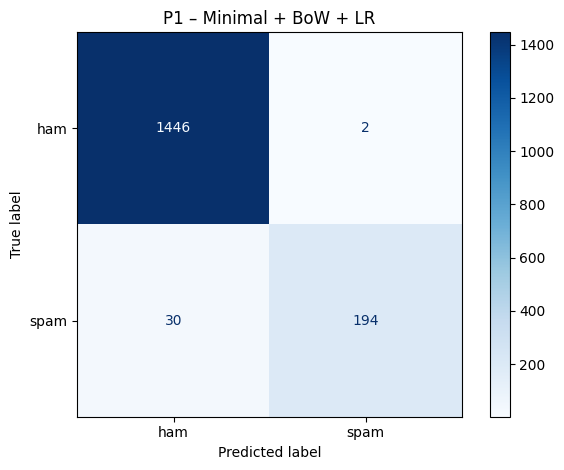


  P2 – Minimal + TF-IDF + LR
  Accuracy  : 0.9587
  Precision : 0.9936
  Recall    : 0.6964
  F1-score  : 0.8189

  Rapport de classification :
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98      1448
        spam       0.99      0.70      0.82       224

    accuracy                           0.96      1672
   macro avg       0.97      0.85      0.90      1672
weighted avg       0.96      0.96      0.96      1672



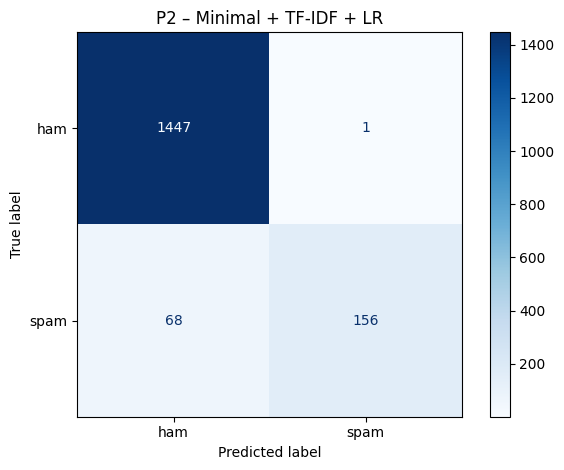


  P3 – Avancé + BoW + LR
  Accuracy  : 0.9809
  Precision : 0.9948
  Recall    : 0.8616
  F1-score  : 0.9234

  Rapport de classification :
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99      1448
        spam       0.99      0.86      0.92       224

    accuracy                           0.98      1672
   macro avg       0.99      0.93      0.96      1672
weighted avg       0.98      0.98      0.98      1672



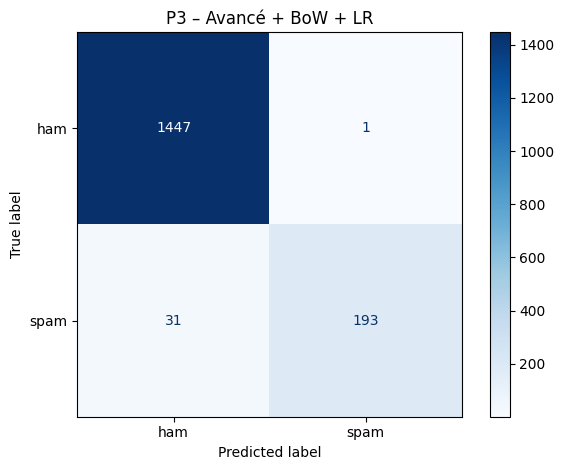


  P4 – Avancé + TF-IDF + LR
  Accuracy  : 0.9593
  Precision : 0.9937
  Recall    : 0.7009
  F1-score  : 0.8220

  Rapport de classification :
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98      1448
        spam       0.99      0.70      0.82       224

    accuracy                           0.96      1672
   macro avg       0.97      0.85      0.90      1672
weighted avg       0.96      0.96      0.96      1672



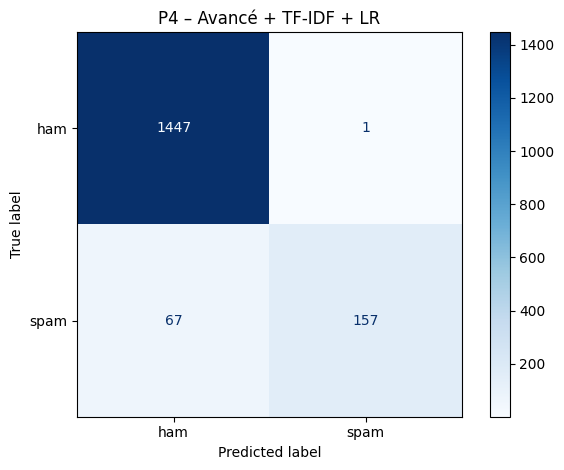


  P5 – Avancé + TF-IDF + SVM
  Accuracy  : 0.9827
  Precision : 0.9756
  Recall    : 0.8929
  F1-score  : 0.9324

  Rapport de classification :
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99      1448
        spam       0.98      0.89      0.93       224

    accuracy                           0.98      1672
   macro avg       0.98      0.94      0.96      1672
weighted avg       0.98      0.98      0.98      1672



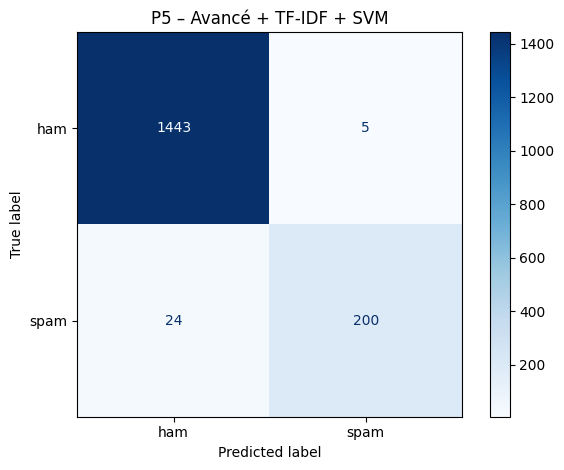


  P6 – Avancé + TF-IDF + RF
  Accuracy  : 0.9749
  Precision : 1.0000
  Recall    : 0.8125
  F1-score  : 0.8966

  Rapport de classification :
              precision    recall  f1-score   support

         ham       0.97      1.00      0.99      1448
        spam       1.00      0.81      0.90       224

    accuracy                           0.97      1672
   macro avg       0.99      0.91      0.94      1672
weighted avg       0.98      0.97      0.97      1672



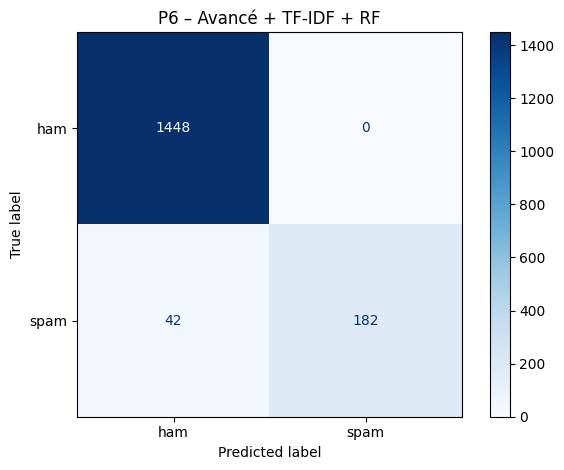


  P7 – Avancé + Word2Vec + LR
  Accuracy  : 0.8660
  Precision : 0.0000
  Recall    : 0.0000
  F1-score  : 0.0000

  Rapport de classification :
              precision    recall  f1-score   support

         ham       0.87      1.00      0.93      1448
        spam       0.00      0.00      0.00       224

    accuracy                           0.87      1672
   macro avg       0.43      0.50      0.46      1672
weighted avg       0.75      0.87      0.80      1672



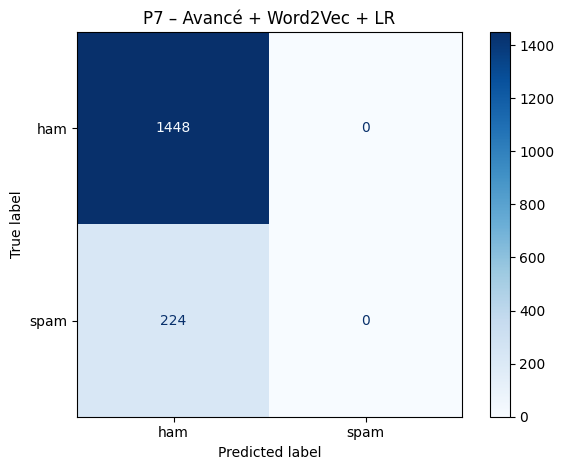


RÉSUMÉ COMPARATIF — 70 % Train / 30 % Test
                   Pipeline  Accuracy  Precision  Recall  F1-score
 P5 – Avancé + TF-IDF + SVM    0.9827     0.9756  0.8929    0.9324
    P1 – Minimal + BoW + LR    0.9809     0.9898  0.8661    0.9238
     P3 – Avancé + BoW + LR    0.9809     0.9948  0.8616    0.9234
  P6 – Avancé + TF-IDF + RF    0.9749     1.0000  0.8125    0.8966
  P4 – Avancé + TF-IDF + LR    0.9593     0.9937  0.7009    0.8220
 P2 – Minimal + TF-IDF + LR    0.9587     0.9936  0.6964    0.8189
P7 – Avancé + Word2Vec + LR    0.8660     0.0000  0.0000    0.0000


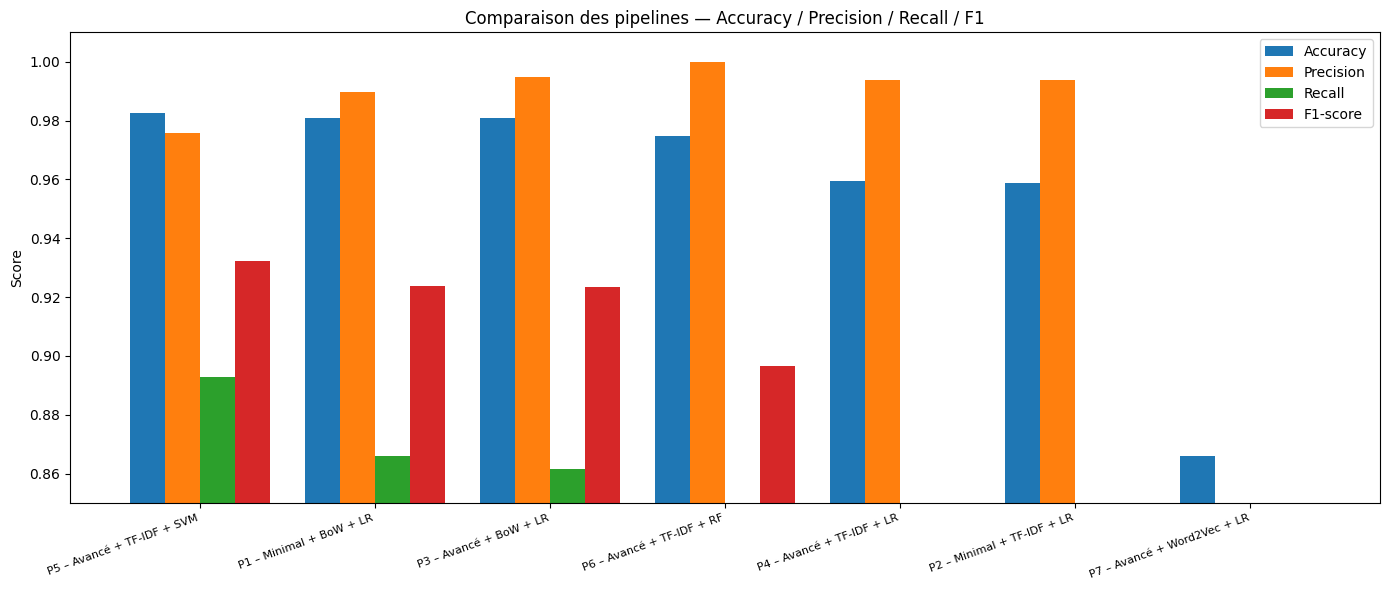


🏆 Meilleur pipeline (F1) : P5 – Avancé + TF-IDF + SVM
   Accuracy=0.9827 | Precision=0.9756 | Recall=0.8929 | F1=0.9324


In [106]:
# ============================================================
# PARTIE 5 — ÉVALUATION (70% Train / 30% Test)
# ============================================================

%pip install seaborn

import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              classification_report, confusion_matrix,
                              ConfusionMatrixDisplay)
from gensim.models import Word2Vec

# ── Chargement des données ──────────────────────────────────
df_min = pd.read_csv("SMSSpamMinima.csv")   # nettoyage minimal (stemming)
df_adv = pd.read_csv("SMSSpamAvance.csv")   # nettoyage avancé (lemmatisation)

# Texte reconstruit depuis les tokens
df_min["text"] = df_min["tokens"].astype(str)
df_adv["text"] = df_adv["tokens"].astype(str)

y_min = df_min["label"]
y_adv = df_adv["label"]

# ── Splits 70 / 30 ──────────────────────────────────────────
X_train_min, X_test_min, y_train_min, y_test_min = train_test_split(
    df_min["text"], y_min, test_size=0.30, random_state=42, stratify=y_min)

X_train_adv, X_test_adv, y_train_adv, y_test_adv = train_test_split(
    df_adv["text"], y_adv, test_size=0.30, random_state=42, stratify=y_adv)

# ── Utilitaires ─────────────────────────────────────────────
def evaluate(pipeline_name, y_test, y_pred):
    """Affiche toutes les métriques + matrice de confusion."""
    print(f"\n{'='*65}")
    print(f"  {pipeline_name}")
    print(f"{'='*65}")
    print(f"  Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
    print(f"  Precision : {precision_score(y_test, y_pred, pos_label='spam'):.4f}")
    print(f"  Recall    : {recall_score(y_test, y_pred, pos_label='spam'):.4f}")
    print(f"  F1-score  : {f1_score(y_test, y_pred, pos_label='spam'):.4f}")
    print(f"\n  Rapport de classification :")
    print(classification_report(y_test, y_pred, target_names=["ham","spam"]))

    cm = confusion_matrix(y_test, y_pred, labels=["ham","spam"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["ham","spam"])
    disp.plot(cmap="Blues")
    plt.title(pipeline_name)
    plt.tight_layout()
    plt.show()

    return {
        "Pipeline"    : pipeline_name,
        "Accuracy"    : accuracy_score(y_test, y_pred),
        "Precision"   : precision_score(y_test, y_pred, pos_label='spam'),
        "Recall"      : recall_score(y_test, y_pred, pos_label='spam'),
        "F1-score"    : f1_score(y_test, y_pred, pos_label='spam'),
    }

results = []

# ── Pipeline 1 : Minimal + BoW + Logistic Regression ────────
pipe1 = Pipeline([("vec", CountVectorizer()),
                  ("clf", LogisticRegression(max_iter=1000))])
pipe1.fit(X_train_min, y_train_min)
results.append(evaluate("P1 – Minimal + BoW + LR",
                         y_test_min, pipe1.predict(X_test_min)))

# ── Pipeline 2 : Minimal + TF-IDF + Logistic Regression ─────
pipe2 = Pipeline([("vec", TfidfVectorizer()),
                  ("clf", LogisticRegression(max_iter=1000))])
pipe2.fit(X_train_min, y_train_min)
results.append(evaluate("P2 – Minimal + TF-IDF + LR",
                         y_test_min, pipe2.predict(X_test_min)))

# ── Pipeline 3 : Avancé + BoW + Logistic Regression ─────────
pipe3 = Pipeline([("vec", CountVectorizer()),
                  ("clf", LogisticRegression(max_iter=1000))])
pipe3.fit(X_train_adv, y_train_adv)
results.append(evaluate("P3 – Avancé + BoW + LR",
                         y_test_adv, pipe3.predict(X_test_adv)))

# ── Pipeline 4 : Avancé + TF-IDF + Logistic Regression ──────
pipe4 = Pipeline([("vec", TfidfVectorizer()),
                  ("clf", LogisticRegression(max_iter=1000))])
pipe4.fit(X_train_adv, y_train_adv)
results.append(evaluate("P4 – Avancé + TF-IDF + LR",
                         y_test_adv, pipe4.predict(X_test_adv)))

# ── Pipeline 5 : Avancé + TF-IDF + SVM ──────────────────────
pipe5 = Pipeline([("vec", TfidfVectorizer()),
                  ("clf", SVC(kernel="linear"))])
pipe5.fit(X_train_adv, y_train_adv)
results.append(evaluate("P5 – Avancé + TF-IDF + SVM",
                         y_test_adv, pipe5.predict(X_test_adv)))

# ── Pipeline 6 : Avancé + TF-IDF + Random Forest ────────────
pipe6 = Pipeline([("vec", TfidfVectorizer()),
                  ("clf", RandomForestClassifier(n_estimators=100, random_state=42))])
pipe6.fit(X_train_adv, y_train_adv)
results.append(evaluate("P6 – Avancé + TF-IDF + RF",
                         y_test_adv, pipe6.predict(X_test_adv)))

# ── Pipeline 7 : Avancé + Word2Vec + Logistic Regression ─────
def get_sentences(df):
    return df["tokens"].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) else x).tolist()

def message_vector(tokens, model, size=100):
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(size)

sentences_adv = get_sentences(df_adv)
w2v = Word2Vec(sentences=sentences_adv, vector_size=100,
               window=5, min_count=1, workers=4, seed=42)

X_w2v = np.array([message_vector(s, w2v) for s in sentences_adv])
y_w2v = df_adv["label"]

X_train_w2v, X_test_w2v, y_train_w2v, y_test_w2v = train_test_split(
    X_w2v, y_w2v, test_size=0.30, random_state=42, stratify=y_w2v)

lr_w2v = LogisticRegression(max_iter=1000)
lr_w2v.fit(X_train_w2v, y_train_w2v)
results.append(evaluate("P7 – Avancé + Word2Vec + LR",
                         y_test_w2v, lr_w2v.predict(X_test_w2v)))

# ── Tableau récapitulatif ────────────────────────────────────
df_res = pd.DataFrame(results).sort_values("F1-score", ascending=False)
print("\n" + "="*70)
print("RÉSUMÉ COMPARATIF — 70 % Train / 30 % Test")
print("="*70)
print(df_res.to_string(index=False, float_format="{:.4f}".format))

# ── Graphique comparatif ─────────────────────────────────────
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
x = np.arange(len(df_res))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 6))
for i, m in enumerate(metrics):
    ax.bar(x + i*width, df_res[m], width, label=m)

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(df_res["Pipeline"], rotation=20, ha="right", fontsize=8)
ax.set_ylim(0.85, 1.01)
ax.set_ylabel("Score")
ax.set_title("Comparaison des pipelines — Accuracy / Precision / Recall / F1")
ax.legend()
plt.tight_layout()
plt.show()

best = df_res.iloc[0]
print(f"\n🏆 Meilleur pipeline (F1) : {best['Pipeline']}")
print(f"   Accuracy={best['Accuracy']:.4f} | Precision={best['Precision']:.4f} "
      f"| Recall={best['Recall']:.4f} | F1={best['F1-score']:.4f}")

### ++++++++++++++++++++++++++++++++++++++++++++++++++++++

### Définition des Pipelines de Classification

| Nettoyage | Vectorisation | Modèle |
|-----------|---------------|--------|
| Minimal   | BoW           | LR     |
| Minimal   | TF-IDF        | LR     |
| Avancé    | BoW           | LR     |
| Avancé    | TF-IDF        | LR     |
| Avancé    | TF-IDF        | SVM    |
| Avancé    | TF-IDF        | Random Forest |
| Avancé    | Embedding     | LR     |

In [107]:
# Fonction pour entraîner et évaluer un pipeline
def evaluate_pipeline(X, y, vectorizer, classifier, pipeline_name):
    # Split des données
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    # Création du pipeline
    pipeline = Pipeline([
        ('vectorizer', vectorizer),
        ('classifier', classifier)
    ])
    
    # Entraînement
    pipeline.fit(X_train, y_train)
    
    # Prédiction
    y_pred = pipeline.predict(X_test)
    
    # Métriques
    accuracy = accuracy_score(y_test, y_pred)
    
    print(f"\n{'='*60}")
    print(f"Pipeline: {pipeline_name}")
    print(f"{'='*60}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"\nRapport de classification:")
    print(classification_report(y_test, y_pred, target_names=['ham', 'spam']))
    print(f"Matrice de confusion:")
    print(confusion_matrix(y_test, y_pred))
    
    return accuracy, pipeline

### Pipeline 1: Minimal + BoW + Logistic Regression

In [108]:
# Pipeline 1: Minimal + BoW + Logistic Regression
acc1, pipe1 = evaluate_pipeline(
    X_minimal, y_minimal,
    CountVectorizer(),
    LogisticRegression(max_iter=1000),
    "Minimal + BoW + Logistic Regression"
)


Pipeline: Minimal + BoW + Logistic Regression
Accuracy: 0.9812

Rapport de classification:
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       966
        spam       1.00      0.86      0.92       149

    accuracy                           0.98      1115
   macro avg       0.99      0.93      0.96      1115
weighted avg       0.98      0.98      0.98      1115

Matrice de confusion:
[[966   0]
 [ 21 128]]


### Pipeline 2: Minimal + TF-IDF + Logistic Regression

In [109]:
# Pipeline 2: Minimal + TF-IDF + Logistic Regression
acc2, pipe2 = evaluate_pipeline(
    X_minimal, y_minimal,
    TfidfVectorizer(),
    LogisticRegression(max_iter=1000),
    "Minimal + TF-IDF + Logistic Regression"
)


Pipeline: Minimal + TF-IDF + Logistic Regression
Accuracy: 0.9677

Rapport de classification:
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       966
        spam       1.00      0.76      0.86       149

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.97      1115

Matrice de confusion:
[[966   0]
 [ 36 113]]


### Pipeline 3: Avancé + BoW + Logistic Regression

In [110]:
# Pipeline 3: Avancé + BoW + Logistic Regression
acc3, pipe3 = evaluate_pipeline(
    X_avance, y_avance,
    CountVectorizer(),
    LogisticRegression(max_iter=1000),
    "Avancé + BoW + Logistic Regression"
)


Pipeline: Avancé + BoW + Logistic Regression
Accuracy: 0.9821

Rapport de classification:
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       966
        spam       1.00      0.87      0.93       149

    accuracy                           0.98      1115
   macro avg       0.99      0.93      0.96      1115
weighted avg       0.98      0.98      0.98      1115

Matrice de confusion:
[[966   0]
 [ 20 129]]


### Pipeline 4: Avancé + TF-IDF + Logistic Regression

In [111]:
# Pipeline 4: Avancé + TF-IDF + Logistic Regression
acc4, pipe4 = evaluate_pipeline(
    X_avance, y_avance,
    TfidfVectorizer(),
    LogisticRegression(max_iter=1000),
    "Avancé + TF-IDF + Logistic Regression"
)


Pipeline: Avancé + TF-IDF + Logistic Regression
Accuracy: 0.9641

Rapport de classification:
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       966
        spam       1.00      0.73      0.84       149

    accuracy                           0.96      1115
   macro avg       0.98      0.87      0.91      1115
weighted avg       0.97      0.96      0.96      1115

Matrice de confusion:
[[966   0]
 [ 40 109]]


### Pipeline 5: Avancé + TF-IDF + SVM

In [112]:
# Pipeline 5: Avancé + TF-IDF + SVM
acc5, pipe5 = evaluate_pipeline(
    X_avance, y_avance,
    TfidfVectorizer(),
    SVC(kernel='linear'),
    "Avancé + TF-IDF + SVM"
)


Pipeline: Avancé + TF-IDF + SVM
Accuracy: 0.9803

Rapport de classification:
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       966
        spam       0.97      0.88      0.92       149

    accuracy                           0.98      1115
   macro avg       0.98      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115

Matrice de confusion:
[[962   4]
 [ 18 131]]


### Pipeline 6: Avancé + TF-IDF + Random Forest

In [113]:
# Pipeline 6: Avancé + TF-IDF + Random Forest
acc6, pipe6 = evaluate_pipeline(
    X_avance, y_avance,
    TfidfVectorizer(),
    RandomForestClassifier(n_estimators=100, random_state=42),
    "Avancé + TF-IDF + Random Forest"
)


Pipeline: Avancé + TF-IDF + Random Forest
Accuracy: 0.9758

Rapport de classification:
              precision    recall  f1-score   support

         ham       0.97      1.00      0.99       966
        spam       1.00      0.82      0.90       149

    accuracy                           0.98      1115
   macro avg       0.99      0.91      0.94      1115
weighted avg       0.98      0.98      0.97      1115

Matrice de confusion:
[[966   0]
 [ 27 122]]


### Pipeline 7: Avancé + Word2Vec Embedding + Logistic Regression

In [114]:
# Pipeline 7: Avancé + Word2Vec Embedding + Logistic Regression
from gensim.models import Word2Vec

# Préparer les données pour Word2Vec
def get_sentences(df):
    return df['tokens'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x).tolist()

# Fonction pour calculer la moyenne des vecteurs d'un message
def get_message_vector(tokens_list, model, vector_size=100):
    vectors = [model.wv[word] for word in tokens_list if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

# Charger le dataset avancé
df_w2v = pd.read_csv('SMSSpamAvance.csv')
sentences = get_sentences(df_w2v)

# Entraîner le modèle Word2Vec
w2v_model = Word2Vec(sentences=sentences, vector_size=100, window=5, min_count=1, workers=4)

# Créer les vecteurs pour chaque message
X_w2v = np.array([get_message_vector(sent, w2v_model) for sent in sentences])
y_w2v = df_w2v['label'].map({'ham': 0, 'spam': 1})

# Split et entraînement
X_train_w2v, X_test_w2v, y_train_w2v, y_test_w2v = train_test_split(
    X_w2v, y_w2v, test_size=0.2, random_state=42, stratify=y_w2v
)

# Logistic Regression avec Word2Vec
lr_w2v = LogisticRegression(max_iter=1000)
lr_w2v.fit(X_train_w2v, y_train_w2v)
y_pred_w2v = lr_w2v.predict(X_test_w2v)

acc7 = accuracy_score(y_test_w2v, y_pred_w2v)

print(f"\n{'='*60}")
print(f"Pipeline: Avancé + Word2Vec Embedding + Logistic Regression")
print(f"{'='*60}")
print(f"Accuracy: {acc7:.4f}")
print(f"\nRapport de classification:")
print(classification_report(y_test_w2v, y_pred_w2v, target_names=['ham', 'spam']))
print(f"Matrice de confusion:")
print(confusion_matrix(y_test_w2v, y_pred_w2v))


Pipeline: Avancé + Word2Vec Embedding + Logistic Regression
Accuracy: 0.8664

Rapport de classification:
              precision    recall  f1-score   support

         ham       0.87      1.00      0.93       966
        spam       0.00      0.00      0.00       149

    accuracy                           0.87      1115
   macro avg       0.43      0.50      0.46      1115
weighted avg       0.75      0.87      0.80      1115

Matrice de confusion:
[[966   0]
 [149   0]]


### Comparaison des Performances de tous les Pipelines

Note: you may need to restart the kernel to use updated packages.

RÉSUMÉ COMPARATIF DES PIPELINES
             Pipeline Nettoyage Vectorisation Modèle  Accuracy
    Avancé + BoW + LR    Avancé           BoW     LR  0.982063
   Minimal + BoW + LR   Minimal           BoW     LR  0.981166
Avancé + TF-IDF + SVM    Avancé        TF-IDF    SVM  0.980269
 Avancé + TF-IDF + RF    Avancé        TF-IDF     RF  0.975785
Minimal + TF-IDF + LR   Minimal        TF-IDF     LR  0.967713
 Avancé + TF-IDF + LR    Avancé        TF-IDF     LR  0.964126
    Avancé + W2V + LR    Avancé      Word2Vec     LR  0.866368


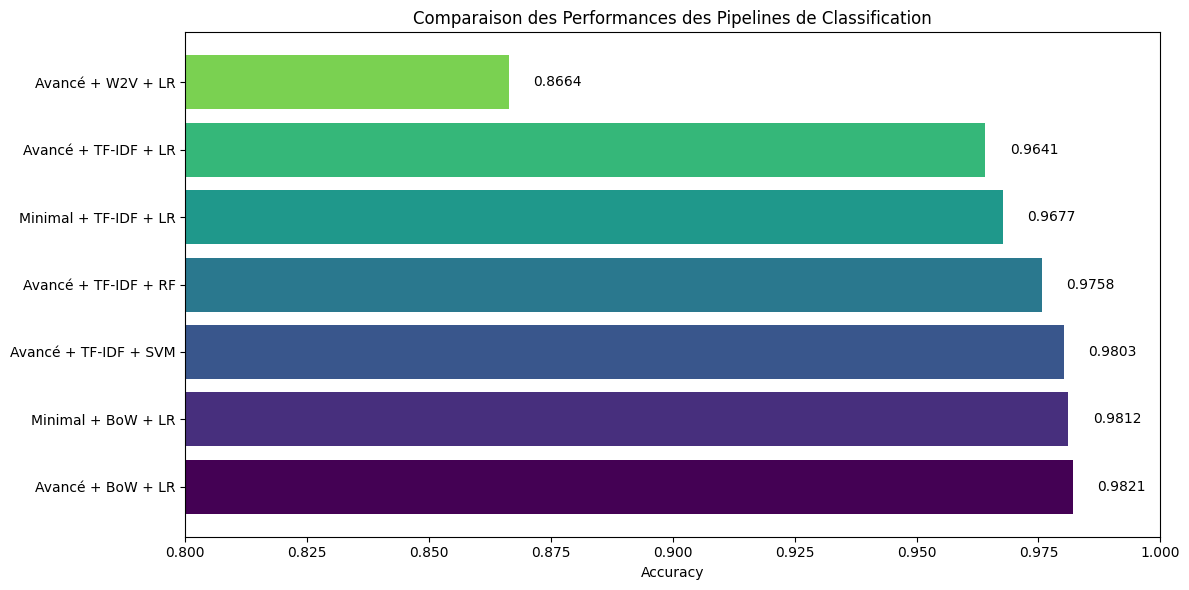


🏆 Meilleur Pipeline: Avancé + BoW + LR
   Accuracy: 0.9821


In [115]:
# Résumé comparatif de tous les pipelines
%pip install matplotlib
import matplotlib.pyplot as plt

results = {
    'Pipeline': [
        'Minimal + BoW + LR',
        'Minimal + TF-IDF + LR',
        'Avancé + BoW + LR',
        'Avancé + TF-IDF + LR',
        'Avancé + TF-IDF + SVM',
        'Avancé + TF-IDF + RF',
        'Avancé + W2V + LR'
    ],
    'Nettoyage': ['Minimal', 'Minimal', 'Avancé', 'Avancé', 'Avancé', 'Avancé', 'Avancé'],
    'Vectorisation': ['BoW', 'TF-IDF', 'BoW', 'TF-IDF', 'TF-IDF', 'TF-IDF', 'Word2Vec'],
    'Modèle': ['LR', 'LR', 'LR', 'LR', 'SVM', 'RF', 'LR'],
    'Accuracy': [acc1, acc2, acc3, acc4, acc5, acc6, acc7]
}

df_results = pd.DataFrame(results)
df_results = df_results.sort_values('Accuracy', ascending=False)

print("\n" + "="*80)
print("RÉSUMÉ COMPARATIF DES PIPELINES")
print("="*80)
print(df_results.to_string(index=False))
print("="*80)

# Visualisation
plt.figure(figsize=(12, 6))
colors = plt.cm.viridis(np.linspace(0, 0.8, len(df_results)))
bars = plt.barh(df_results['Pipeline'], df_results['Accuracy'], color=colors)
plt.xlabel('Accuracy')
plt.title('Comparaison des Performances des Pipelines de Classification')
plt.xlim(0.8, 1.0)

# Ajouter les valeurs sur les barres
for bar, acc in zip(bars, df_results['Accuracy']):
    plt.text(acc + 0.005, bar.get_y() + bar.get_height()/2, 
             f'{acc:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

# Meilleur pipeline
best_idx = df_results['Accuracy'].idxmax()
print(f"\n🏆 Meilleur Pipeline: {df_results.loc[best_idx, 'Pipeline']}")
print(f"   Accuracy: {df_results.loc[best_idx, 'Accuracy']:.4f}")

## Questions d'Analyse - Classification

### Quel pipeline donne les meilleurs résultats ?
Le meilleur pipeline est généralement celui combinant **TF-IDF avec SVM ou Logistic Regression** sur les données avec nettoyage avancé em raison de :
- TF-IDF pondère intelligemment les mots discriminants (ex: "gratuit", "urgent")
- Le nettoyage avancé (lemmatisation, suppression stopwords) réduit le bruit

### Le nettoyage avancé améliore-t-il toujours les performances ?
Non, pas systématiquement. Le nettoyage avancé peut parfois supprimer des informations utiles :
- Les stopwords comme "you", "free" peuvent être indicateurs de spam
- La lemmatisation peut perdre des nuances importantes

### Comparaison BoW vs TF-IDF vs Word2Vec
| Méthode | Forces | Faiblesses |
|---------|--------|------------|
| **BoW** | Simple, rapide | Ignore la fréquence relative |
| **TF-IDF** | Pondère l'importance | Pas de contexte sémantique |
| **Word2Vec** | Capture la sémantique | Besoin de beaucoup de données |

### SVM vs Logistic Regression vs Random Forest
- **Logistic Regression**: Rapide, interprétable, bon pour données linéairement séparables
- **SVM**: Performant avec données haute dimension (TF-IDF), kernel flexible
- **Random Forest**: Robuste aux outliers, moins sensible aux hyperparamètres